# Assignment 1: MVU and CRLB (Estimation)

__2c__

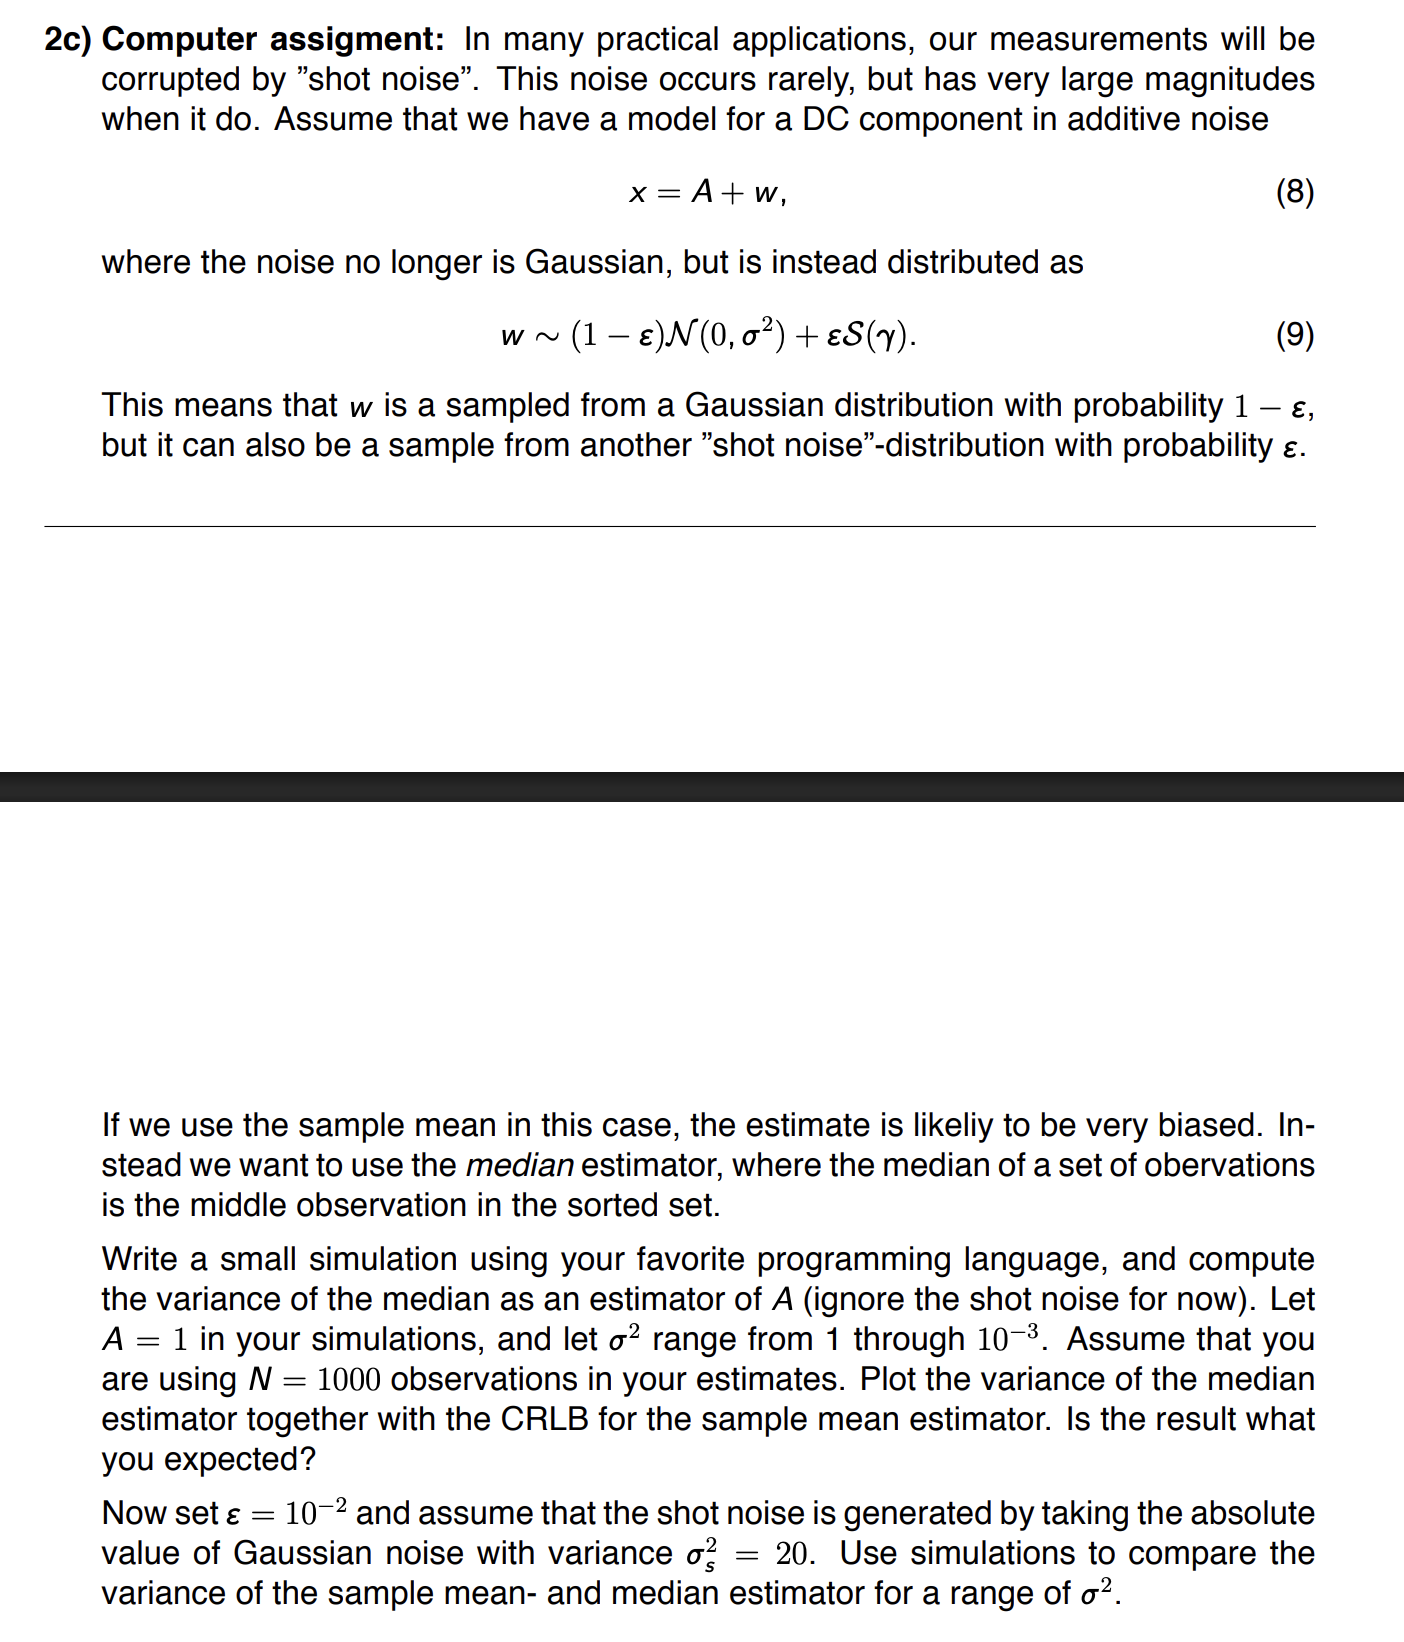

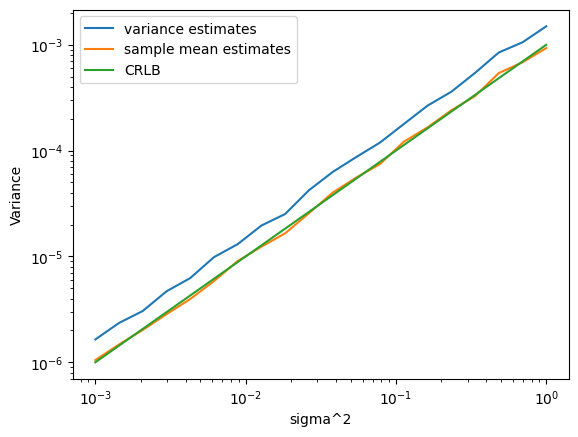

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# defining constants
A = 1
sigma_squared_values = np.logspace(0, -3, 20)
N = 1000                                    # number of observations
M = 1000                                   # number of simulations
variance_estimates = []
sample_mean = []

# simulation
for sigma2 in sigma_squared_values:
    sigma = np.sqrt(sigma2)
    median_estimates = []
    sample_mean_estimates = []

    for i in range(M):
        w = np.random.normal(loc=0, scale=sigma, size=N)
        x = A + w
        A_hat = np.median(x)
        A_mean = np.mean(x)
        median_estimates.append(A_hat)
        sample_mean_estimates.append(A_mean)

    var = np.var(median_estimates)
    mean_var = np.var(sample_mean_estimates)

    variance_estimates.append(var)
    sample_mean.append(mean_var)

crlb_values = sigma_squared_values/N

# plotted variance of median with CRLB
plt.plot(sigma_squared_values, variance_estimates, label="variance estimates")
plt.plot(sigma_squared_values, sample_mean, label="sample mean estimates")
plt.plot(sigma_squared_values, crlb_values, label="CRLB")

plt.xscale("log")
plt.xlabel("sigma^2")
plt.yscale("log")
plt.ylabel("Variance")
plt.legend()

plt.show()


First plot shows that CRLB achieves lower bound, as proven earlier in the excercise. The estimator is efficient - the sample mean is an efficient estimator of A for Gaussian noise. 

Now we add shot noise

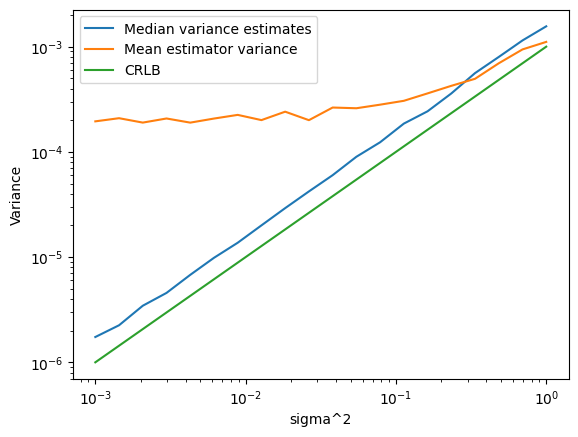

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# defining constants
A = 1
sigma_squared_values = np.logspace(0, -3, 20)
N = 1000                                    # number of observations
M = 1000                                   # number of simulations
median_variance_estimates = []

# shot noise
epsilon = 1e-2
sigma_s_squared = 20
mean_variance_estimates = []

# simulation
for sigma2 in sigma_squared_values:
    sigma = np.sqrt(sigma2)
    median_estimates = []
    mean_estimates = []

    for i in range(M):
        w = np.random.normal(loc=0, scale=sigma, size=N)
        spikes = np.random.binomial(1, epsilon, N)
        shot_noise = np.random.normal(0, np.sqrt(sigma_s_squared), N)
        s = spikes * shot_noise

        x = A + w + s

        A_hat_median = np.median(x)
        A_hat_mean = np.mean(x)

        median_estimates.append(A_hat_median)
        mean_estimates.append(A_hat_mean)

    median_var = np.var(median_estimates, ddof=1)
    mean_var = np.var(mean_estimates, ddof=1)

    median_variance_estimates.append(median_var)
    mean_variance_estimates.append(mean_var)

crlb_values = sigma_squared_values/N

# plotted variance of median with CRLB
plt.plot(sigma_squared_values, median_variance_estimates, label="Median variance estimates")
plt.plot(sigma_squared_values, mean_variance_estimates, label="Mean estimator variance")
plt.plot(sigma_squared_values, crlb_values, label="CRLB")

plt.xscale("log")
plt.xlabel("sigma^2")
plt.yscale("log")
plt.ylabel("Variance")
plt.legend()

plt.show()


Plot makes sense. With shot noise, the mean is affected by the extreme values, while the median remains better because it only orders the values and takes the median. While with no shot noise, it makes sense that the mean is better than the median. 